# Missing Data EDA

This notebook performs a clean, readable exploratory analysis of missingness in the merged school dataset.

## Goals
- Load and lightly clean the merged dataset
- Summarize missing values across all features
- Visualize missingness patterns by school type
- Inspect the distribution of schools across school types
- Repeat the missingness analysis for public high schools only


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
# -----------------------------
# Configuration
# -----------------------------
DATA_PATH = "../cleaned_data/final_merged_dataset.csv"
GROUP_COL = "School Type"

MISSINGNESS_COLUMNS_TO_CHECK = [
    "Percentage Standard Met and Above",
    "Students Tested with Scores (Rate)",
    "College Going Rate - Total (12 Months)",
]

In [3]:
# -----------------------------
# Load and clean data
# -----------------------------
df = pd.read_csv(DATA_PATH).drop(columns=["Unnamed: 0"], errors="ignore")

# In this dataset, "*" is used as a suppressed / unavailable value.
# Treat it as missing so it is counted consistently in the analysis.
df = df.replace("*", np.nan)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Rows: 935
Columns: 21


In [4]:
df.head()

,SchoolCode,School Name,Charter School,DASS,ChronicAbsenteeismRate,College Going Rate - Total (12 Months),TOTAL_EL,Percent Eligible FRPM,School Type,Educational Option Type,Met UC/CSU Grad Req's (Rate),Dropout (Rate),Homeless Student Enrollment (Rate),SPED_ENR_N,Stability Rate (percent),CumulativeEnrollment,Total Expulsions,Total Suspensions,STU_TCH_RATIO,Percentage Standard Met and Above,Students Tested with Scores (Rate)
0,130229,Alameda High,No,No,10.9,82.8,100,0.304069,High Schools (Public),Traditional,77.1,0.2,0.005252,235,96.7,1904,0,24,23.8,67.60,0.997674
1,130450,Albany High,No,No,18.3,81.5,72,0.310160,High Schools (Public),Traditional,77.6,0.0,0.006119,92,97.2,1144,0,9,18.8,70.86,0.936027
2,132746,Emery Secondary,No,No,39.2,60.0,18,0.604938,High Schools (Public),Traditional,11.4,4.3,0.011364,24,86.9,176,0,15,11.7,2.94,0.971429
3,134270,Irvington High,No,No,10.7,88.1,160,0.246639,High Schools (Public),Traditional,70.0,3.0,0.013964,158,94.6,2220,0,29,25.4,71.31,0.990138
4,134452,John F. Kennedy High,No,No,15.9,75.4,267,0.527101,High Schools (Public),Traditional,54.3,3.6,0.026608,207,88.3,1353,3,111,20.6,34.23,0.973856


## Helper functions

In [5]:
def summarize_missingness(dataframe: pd.DataFrame) -> pd.DataFrame:
    """Return a table with missing counts and percentages for each column."""
    missing_count = dataframe.isna().sum()
    missing_percent = dataframe.isna().mean() * 100

    summary = pd.DataFrame(
        {
            "Missing Count": missing_count,
            "Percent Missing": missing_percent,
        }
    ).sort_values("Percent Missing", ascending=False)

    return summary


def plot_missingness(summary_df: pd.DataFrame, include_zero_bucket: bool = True, rotation: int = 60) -> None:
    """Plot percent missing by feature, optionally adding an 'All Other Features' zero-missing bar."""
    missing_only = summary_df[summary_df["Percent Missing"] > 0]["Percent Missing"].copy()

    if include_zero_bucket:
        missing_only.loc["All Other Features"] = 0

    missing_only.plot(kind="bar")
    plt.ylabel("Percent Missing")
    plt.title("Missing Data by Feature")
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    plt.show()


def plot_missing_by_group(
    dataframe: pd.DataFrame,
    group_col: str,
    target_col: str,
    rotation: int = 45,
) -> pd.Series:
    """Plot the fraction missing in a target column within each group."""
    missing_rate = dataframe.groupby(group_col)[target_col].apply(lambda x: x.isna().mean())

    missing_rate.plot(kind="bar")
    plt.ylabel("Fraction Missing")
    plt.title(f'Missing "{target_col}" by {group_col}')
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    plt.show()

    return missing_rate


def plot_category_counts(dataframe: pd.DataFrame, column: str, rotation: int = 45) -> pd.Series:
    """Plot the number of records in each category of a column."""
    counts = dataframe[column].value_counts(dropna=False)

    counts.plot(kind="bar")
    plt.xlabel(column)
    plt.ylabel("Number of Schools")
    plt.title(f"Distribution of Schools by {column}")
    plt.xticks(rotation=rotation, ha="right")
    plt.tight_layout()
    plt.show()

    return counts

## Overall dataset overview

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 935 entries, 0 to 934
Data columns (total 21 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   SchoolCode                              935 non-null    int64  
 1   School Name                             935 non-null    object 
 2   Charter School                          935 non-null    object 
 3   DASS                                    935 non-null    object 
 4   ChronicAbsenteeismRate                  935 non-null    float64
 5   College Going Rate - Total (12 Months)  923 non-null    float64
 6   TOTAL_EL                                935 non-null    int64  
 7   Percent Eligible FRPM                   935 non-null    float64
 8   School Type                             935 non-null    object 
 9   Educational Option Type                 935 non-null    object 
 10  Met UC/CSU Grad Req's (Rate)            930 non-null    float6

In [7]:
df.describe(include="all").T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
SchoolCode,935.0,NaN,NaN,NaN,2253746.810695,1739022.964297,100065.0,137699.0,1938356.0,3730177.0,5838305.0
School Name,935,885,Foothill High,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Charter School,935,2,No,828,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DASS,935,2,No,929,NaN,NaN,NaN,NaN,NaN,NaN,NaN
ChronicAbsenteeismRate,935.0,NaN,NaN,NaN,22.388877,10.821801,0.0,14.85,20.4,28.4,96.9
College Going Rate - Total (12 Months),923.0,NaN,NaN,NaN,68.290791,13.93656,9.6,58.05,69.4,79.3,96.5
TOTAL_EL,935.0,NaN,NaN,NaN,165.582888,149.55116,1.0,50.5,123.0,242.5,1201.0
Percent Eligible FRPM,935.0,NaN,NaN,NaN,0.647557,0.248919,0.034453,0.457663,0.705202,0.862731,0.992347
School Type,935,1,High Schools (Public),935,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Educational Option Type,935,1,Traditional,935,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Overall missingness summary

In [8]:
missing_summary = summarize_missingness(df)
missing_summary.head(25)

,Missing Count,Percent Missing
Percentage Standard Met and Above,41,4.385027
Students Tested with Scores (Rate),14,1.497326
College Going Rate - Total (12 Months),12,1.283422
Dropout (Rate),5,0.534759
Met UC/CSU Grad Req's (Rate),5,0.534759
ChronicAbsenteeismRate,0,0.000000
TOTAL_EL,0,0.000000
Percent Eligible FRPM,0,0.000000
School Type,0,0.000000
Educational Option Type,0,0.000000


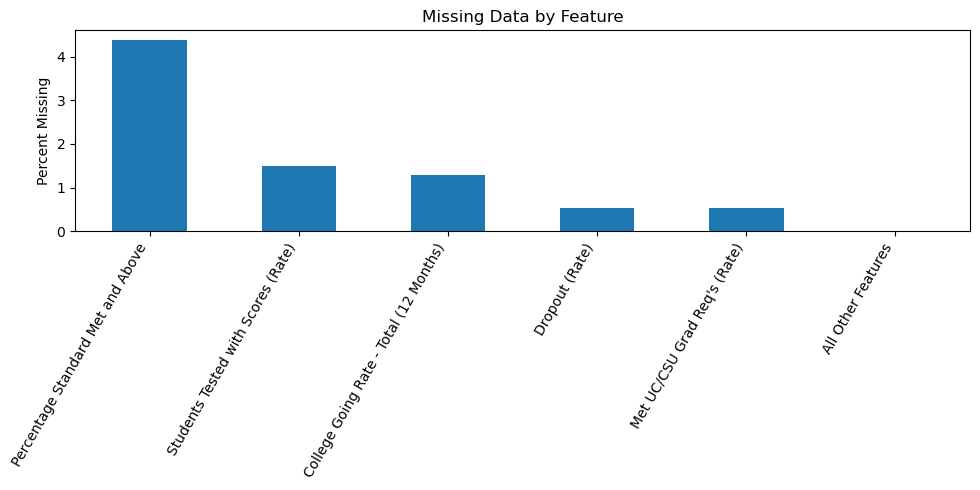

In [9]:
plot_missingness(missing_summary, include_zero_bucket=True, rotation=60)

## Missingness by school type for key variables

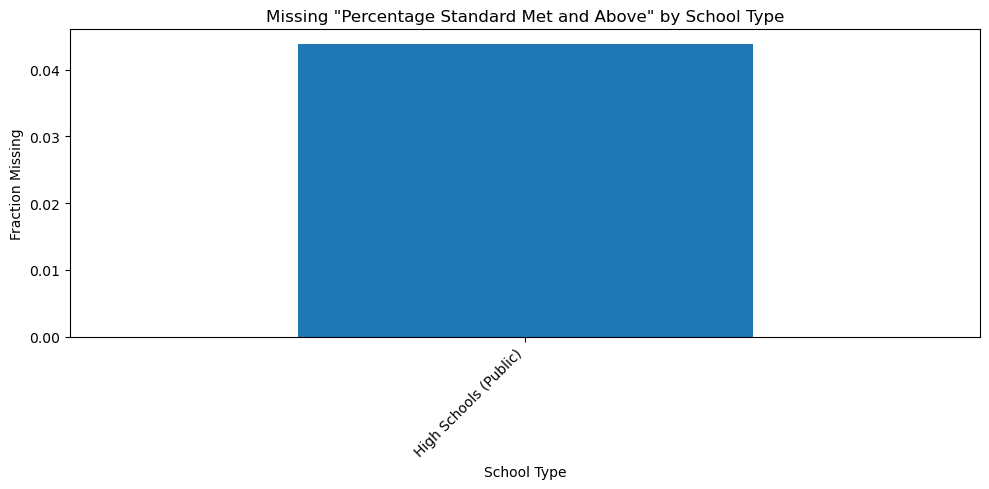

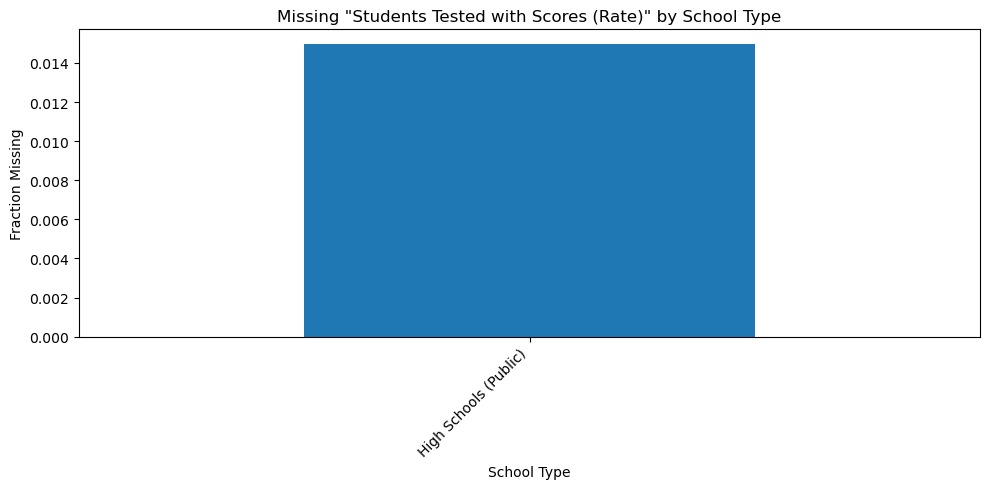

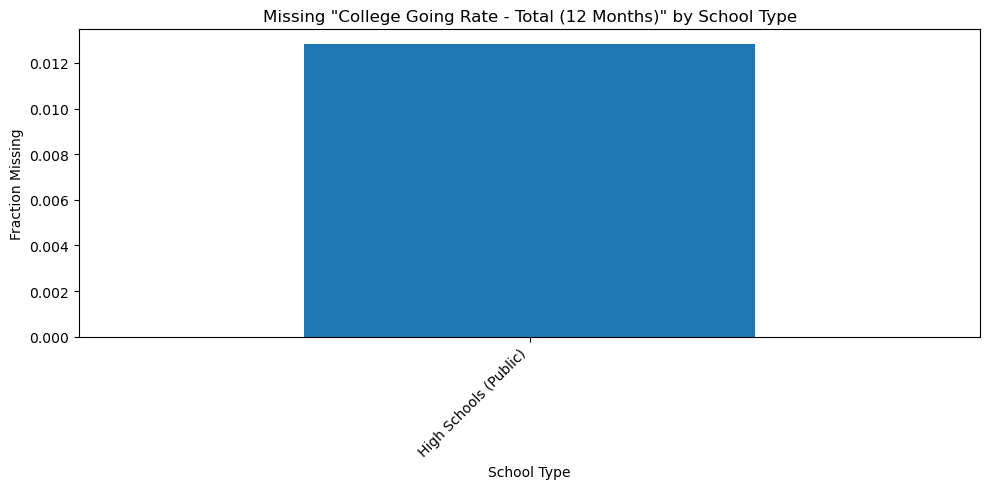

In [10]:
for column in MISSINGNESS_COLUMNS_TO_CHECK:
    if column in df.columns:
        plot_missing_by_group(df, GROUP_COL, column, rotation=45)
    else:
        print(f"Column not found: {column}")

## Restrict to public high schools

In [11]:
high_school_df = df[df[GROUP_COL] == "High Schools (Public)"].copy()

print(f"Public high schools: {high_school_df.shape[0]:,}")
high_school_df.head()

Public high schools: 935


,SchoolCode,School Name,Charter School,DASS,ChronicAbsenteeismRate,College Going Rate - Total (12 Months),TOTAL_EL,Percent Eligible FRPM,School Type,Educational Option Type,Met UC/CSU Grad Req's (Rate),Dropout (Rate),Homeless Student Enrollment (Rate),SPED_ENR_N,Stability Rate (percent),CumulativeEnrollment,Total Expulsions,Total Suspensions,STU_TCH_RATIO,Percentage Standard Met and Above,Students Tested with Scores (Rate)
0,130229,Alameda High,No,No,10.9,82.8,100,0.304069,High Schools (Public),Traditional,77.1,0.2,0.005252,235,96.7,1904,0,24,23.8,67.60,0.997674
1,130450,Albany High,No,No,18.3,81.5,72,0.310160,High Schools (Public),Traditional,77.6,0.0,0.006119,92,97.2,1144,0,9,18.8,70.86,0.936027
2,132746,Emery Secondary,No,No,39.2,60.0,18,0.604938,High Schools (Public),Traditional,11.4,4.3,0.011364,24,86.9,176,0,15,11.7,2.94,0.971429
3,134270,Irvington High,No,No,10.7,88.1,160,0.246639,High Schools (Public),Traditional,70.0,3.0,0.013964,158,94.6,2220,0,29,25.4,71.31,0.990138
4,134452,John F. Kennedy High,No,No,15.9,75.4,267,0.527101,High Schools (Public),Traditional,54.3,3.6,0.026608,207,88.3,1353,3,111,20.6,34.23,0.973856


In [12]:
high_school_missing_summary = summarize_missingness(high_school_df)
high_school_missing_summary.head(25)

,Missing Count,Percent Missing
Percentage Standard Met and Above,41,4.385027
Students Tested with Scores (Rate),14,1.497326
College Going Rate - Total (12 Months),12,1.283422
Dropout (Rate),5,0.534759
Met UC/CSU Grad Req's (Rate),5,0.534759
ChronicAbsenteeismRate,0,0.000000
TOTAL_EL,0,0.000000
Percent Eligible FRPM,0,0.000000
School Type,0,0.000000
Educational Option Type,0,0.000000


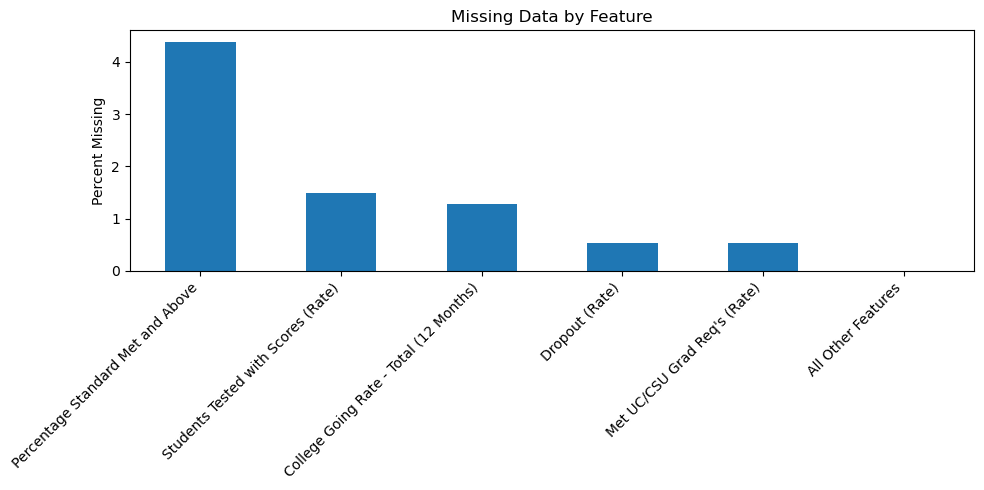

In [13]:
plot_missingness(high_school_missing_summary, include_zero_bucket=True, rotation=45)